In [2]:
import seaborn as sns 
from sklearn.datasets import make_blobs

In [3]:
X,y=make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

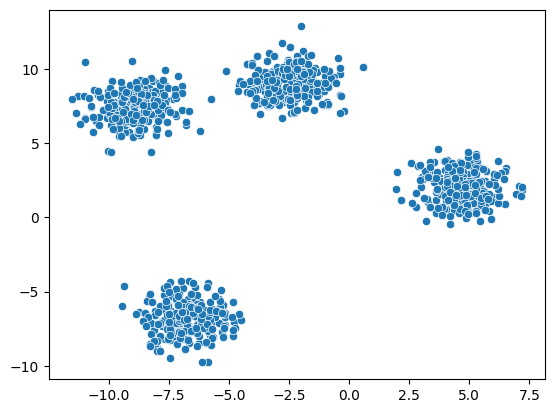

In [4]:
sns.scatterplot(x=X[:,0],y=X[:,1])

In [6]:
from sklearn.cluster import KMeans

In [7]:
K=4
model=KMeans(
    n_clusters=K,
    random_state=42
)

In [12]:
labels=model.fit_predict(X)

<Axes: >

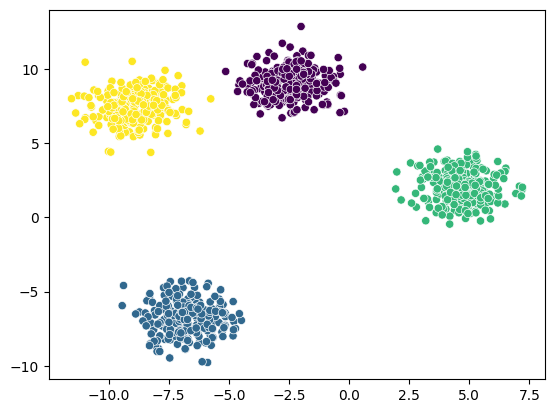

In [13]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

# Choosing our k values

<Axes: >

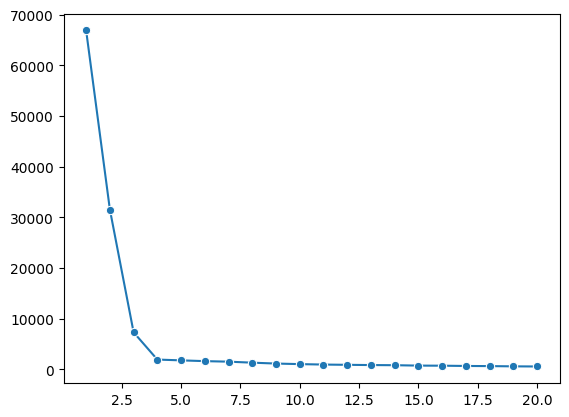

In [18]:
#Elbow method
wcss=[]
for k in range(1,21):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
sns.lineplot(x=range(1,21),y=wcss,marker="o")

In [24]:
from kneed import KneeLocator
knee=KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")
best_K=knee.elbow
print("Best K val =",best_K)

Best K val= 4


In [26]:
from sklearn.metrics import silhouette_score
ss=[]
for k in range(2,21):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X)
    ss.append(silhouette_score(X,labels))
    

<Axes: >

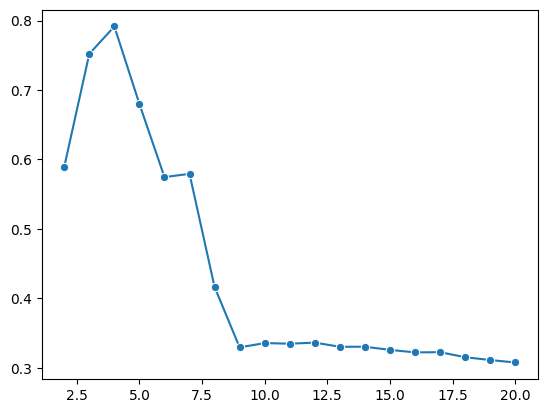

In [28]:
sns.lineplot(x=range(2,21),y=ss,marker="o")

# KMeans for Iris

In [30]:
from  sklearn.datasets import load_iris

In [31]:
iris=load_iris()

In [32]:
X=iris.data
y=iris.target

In [36]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [57]:
#Dimensionality reduction 
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_scaled)

[574.8792432000106,
 197.4038160454129,
 115.18647050742705,
 90.06894937752107,
 80.88621939050893,
 60.10066050267456,
 51.493248348771886,
 44.26629720937855,
 38.476603902926435,
 33.75815792420379]

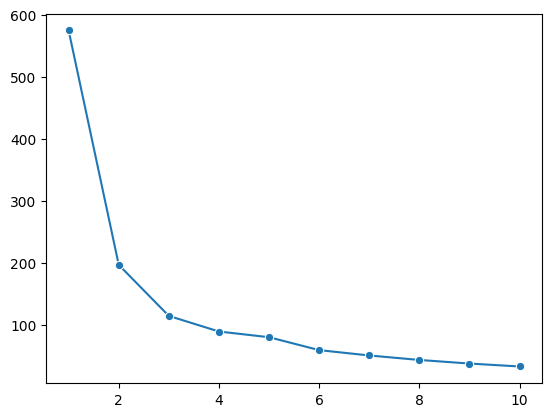

In [58]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
sns.lineplot(x=range(1,11),y=wcss,marker="o") 
wcss

<Axes: >

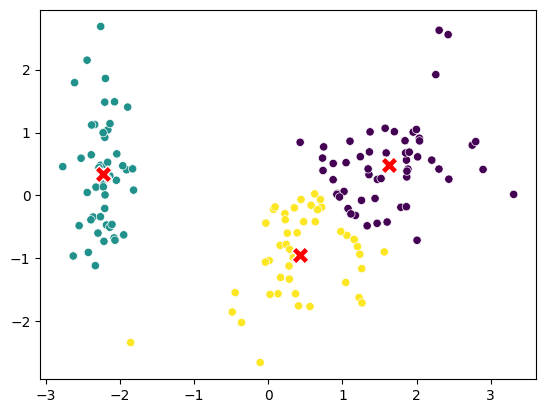

In [68]:
K=3
Kmeans=KMeans(n_clusters=K,random_state=10)
label=Kmeans.fit_predict(pca_data)
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=label)
sns.scatterplot(x=Kmeans.cluster_centers_[:,0],y=Kmeans.cluster_centers_[:,1],marker="X",c="red",s=150)